# 17 — Class-Weighted MTL: Mengatasi O-Label Dominance

**Hipotesis**: O-label dominance (~85% token adalah O) menyebabkan semua auxiliary task (ATE, SLD, ASD) di MTL secara bersamaan bias ke prediksi O. Augmentasi via O-token perturbation memperparah ini. Class-weighted loss pada semua auxiliary CE loss diharapkan melawan bias tersebut.

**Key insight dari NB16**: SLD *terbukti membantu* (menghapus SLD turunkan F1 −0.0104 di Original), jadi arsitektur NB03 penuh dipertahankan. Hanya loss weighting yang ditambahkan.

**Arsitektur**: Identik NB03 — two-phase training (3ep SLD pre-train → sentiment connection → 50ep full), **+** `ate_weights`, `sld_weights`, `asd_weights` pada setiap CrossEntropyLoss auxiliary.

**Dua run** (apple-to-apple dengan NB10/NB16):
- `MT + Original (Weighted)`: 2,083 train / 368 val — weights dari original train split
- `MT + Augmented (Weighted)`: 4,290 train / 368 val — weights dari augmented train split

**Weight formula**: sklearn balanced → `w_c = N / (n_classes × count_c)`, normalized.

In [1]:
import gc
import json
import os
import string
import time

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
from torchcrf import CRF
from seqeval.metrics import classification_report, f1_score as seq_f1_score
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {device}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')

PyTorch : 2.5.1+cu121
Device  : cuda
GPU     : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM    : 8.0 GB


In [2]:
# Paths
BASE_DIR      = os.path.dirname(os.getcwd())
DATA_RAW_DIR  = os.path.join(BASE_DIR, 'data', 'raw')
DATA_PROC_DIR = os.path.join(BASE_DIR, 'data', 'processed')
MODEL_DIR     = os.path.join(BASE_DIR, 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

BIEOS_PATH           = os.path.join(DATA_PROC_DIR, 'train_data_bieos.json')
BIEOS_AUG_TRAIN_PATH = os.path.join(DATA_PROC_DIR, 'train_data_bieos_augmented_train.json')
BIEOS_AUG_VAL_PATH   = os.path.join(DATA_PROC_DIR, 'train_data_bieos_val.json')
POS_LEX_PATH = os.path.join(DATA_RAW_DIR, 'indonesian_sentiment_lexicon_positive.tsv')
NEG_LEX_PATH = os.path.join(DATA_RAW_DIR, 'indonesian_sentiment_lexicon_negative.tsv')

# Model
MODEL_NAME = 'indobenchmark/indobert-large-p2'
MAX_LENGTH = 128
PROJ_DIM   = 256

# Training
BATCH_SIZE            = 4
GRADIENT_ACCUMULATION = 4
PHASE1_EPOCHS         = 3
NUM_EPOCHS            = 50
PATIENCE              = 10
LR_BERT               = 2e-5
LR_HEAD               = 1e-4
WARMUP_RATIO          = 0.1
WEIGHT_DECAY          = 0.01
MAX_GRAD_NORM         = 1.0
TRAIN_RATIO           = 0.85
SEED                  = 42

# Architecture
DROPOUT     = 0.1
LAMBDA1     = 0.3
LAMBDA2     = 0.3
MAX_REL_POS = 20
IGNORE_INDEX = -100

# Reference F1 (NB10 dan NB16)
PRIOR_RESEARCH_F1 = 0.6761
NB03_MT_F1        = 0.7410
NB07_ST_F1        = 0.7551
NB10_MT_ORIG_F1   = 0.7578
NB10_ST_ORIG_F1   = 0.7558
NB10_MT_AUG_F1    = 0.7442
NB10_ST_AUG_F1    = 0.7600
NB16_MT_ORIG_F1   = 0.7474
NB16_MT_AUG_F1    = 0.7458

torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f'Model   : {MODEL_NAME}')
print(f'Epochs  : P1={PHASE1_EPOCHS} + P2={NUM_EPOCHS} (patience={PATIENCE})')
print(f'Loss    : λ1*(L_ATE+L_SLD) + λ2*L_ASD + L_CRF  [DENGAN class weights]')
print(f'λ1={LAMBDA1}, λ2={LAMBDA2}')

Model   : indobenchmark/indobert-large-p2
Epochs  : P1=3 + P2=50 (patience=10)
Loss    : λ1*(L_ATE+L_SLD) + λ2*L_ASD + L_CRF  [DENGAN class weights]
λ1=0.3, λ2=0.3


In [3]:
class CrossAttentionASD(nn.Module):
    """Cross-attention dari h_ae (ATE) ke h_sl (SLD) dengan relative position encoding."""

    def __init__(self, dim, max_relative_position=20):
        super().__init__()
        self.max_rel_pos = max_relative_position
        self.pos_embedding = nn.Embedding(2 * max_relative_position + 1, dim)
        self.W_ae  = nn.Linear(dim, dim, bias=False)
        self.W_sl  = nn.Linear(dim, dim, bias=False)
        self.W_pos = nn.Linear(dim, dim, bias=False)
        self.bias  = nn.Parameter(torch.zeros(dim))
        self.w_s   = nn.Linear(dim, 1, bias=False)

    def forward(self, h_ae, h_sl, mask=None):
        batch, seq_len, dim = h_ae.shape
        pos = torch.arange(seq_len, device=h_ae.device)
        rel_pos = (pos.unsqueeze(0) - pos.unsqueeze(1)).clamp(
            -self.max_rel_pos, self.max_rel_pos) + self.max_rel_pos
        p_ij = self.pos_embedding(rel_pos)

        s_ae  = self.W_ae(h_ae)
        s_sl  = self.W_sl(h_sl)
        s_pos = self.W_pos(p_ij)

        combined = s_ae.unsqueeze(2) + s_sl.unsqueeze(1) + s_pos.unsqueeze(0) + self.bias
        scores   = self.w_s(torch.tanh(combined)).squeeze(-1)

        if mask is not None:
            scores = scores.masked_fill(~mask.unsqueeze(1), float('-inf'))

        attn_weights = torch.softmax(scores, dim=-1)
        return torch.bmm(attn_weights, h_sl)


print('CrossAttentionASD defined.')

CrossAttentionASD defined.


In [4]:
class HierarchicalMultiTaskABSA(nn.Module):
    """NB03 architecture + class-weighted loss untuk ATE, SLD, ASD."""

    def __init__(self, model_name, num_ate, num_sld, num_asd, num_final,
                 proj_dim=256, dropout=0.1,
                 ate_weights=None, sld_weights=None, asd_weights=None,
                 max_relative_position=20, lambda1=0.3, lambda2=0.3):
        super().__init__()
        self.lambda1  = lambda1
        self.lambda2  = lambda2
        self.num_sld  = num_sld
        self.num_asd  = num_asd

        # Simpan weights sebagai buffer agar ikut pindah device
        self.register_buffer('ate_weights', ate_weights)
        self.register_buffer('sld_weights', sld_weights)
        self.register_buffer('asd_weights', asd_weights)

        self.bert = AutoModel.from_pretrained(
            model_name, use_safetensors=True, low_cpu_mem_usage=True)
        bert_dim = self.bert.config.hidden_size

        # Task 1: ATE + Prior Embedding
        self.ate_proj       = nn.Sequential(
            nn.Linear(bert_dim + num_ate, proj_dim), nn.GELU(), nn.Dropout(dropout))
        self.ate_classifier = nn.Linear(proj_dim, num_ate)

        # Task 2: SLD
        self.sld_proj       = nn.Sequential(
            nn.Linear(bert_dim, proj_dim), nn.GELU(), nn.Dropout(dropout))
        self.sld_classifier = nn.Linear(proj_dim, num_sld)

        # Task 3: ASD via Cross-Attention (h_ae → h_sl)
        self.cross_attention = CrossAttentionASD(proj_dim, max_relative_position)
        self.asd_classifier  = nn.Linear(proj_dim, num_asd)

        # Task 4: Final CRF
        self.final_proj    = nn.Sequential(
            nn.Linear(proj_dim * 2, proj_dim), nn.GELU(), nn.Dropout(dropout))
        self.final_emission = nn.Linear(proj_dim, num_final)
        self.crf            = CRF(num_final, batch_first=True)

        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids, attention_mask, prior_probs=None,
                ate_labels=None, sld_labels=None, asd_labels=None,
                crf_labels=None, **kwargs):
        h = self.dropout(
            self.bert(input_ids=input_ids,
                      attention_mask=attention_mask).last_hidden_state)

        # ATE
        if prior_probs is not None:
            h_with_prior = torch.cat([h, prior_probs], dim=-1)
        else:
            h_with_prior = torch.cat(
                [h, torch.zeros(*h.shape[:-1],
                                self.ate_classifier.out_features,
                                device=h.device)], dim=-1)
        h_ae       = self.ate_proj(h_with_prior)
        ate_logits = self.ate_classifier(h_ae)

        # SLD
        h_sl       = self.sld_proj(h)
        sld_logits = self.sld_classifier(h_sl)

        # ASD via Cross-Attention
        mask       = attention_mask.bool()
        h_sd       = self.cross_attention(h_ae, h_sl, mask=mask)
        asd_logits = self.asd_classifier(h_sd)

        # CRF
        h_concat  = torch.cat([h_ae, h_sd], dim=-1)
        emissions = self.final_emission(self.final_proj(h_concat))

        outputs = {'ate_logits': ate_logits, 'sld_logits': sld_logits,
                   'asd_logits': asd_logits, 'emissions': emissions}

        if ate_labels is not None:
            # Class-weighted CE untuk semua auxiliary task
            ce_ate = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX,
                                         weight=self.ate_weights)
            ce_sld = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX,
                                         weight=self.sld_weights)
            ce_asd = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX,
                                         weight=self.asd_weights)

            loss_ate = ce_ate(ate_logits.view(-1, ate_logits.size(-1)),
                              ate_labels.view(-1))
            loss_sld = ce_sld(sld_logits.view(-1, sld_logits.size(-1)),
                              sld_labels.view(-1))
            loss_asd = ce_asd(asd_logits.view(-1, asd_logits.size(-1)),
                              asd_labels.view(-1))
            loss_crf = -self.crf(emissions.float(), crf_labels,
                                  mask=mask, reduction='mean')

            # L = λ1*(L_ATE + L_SLD) + λ2*L_ASD + L_CRF  (Paper Eq. 10)
            outputs['loss'] = (self.lambda1 * (loss_ate + loss_sld)
                               + self.lambda2 * loss_asd
                               + loss_crf)
            outputs['losses'] = {
                'ate': loss_ate.detach(), 'sld': loss_sld.detach(),
                'asd': loss_asd.detach(), 'crf': loss_crf.detach()}

        return outputs

    def decode(self, emissions, attention_mask):
        return self.crf.decode(emissions.float(), mask=attention_mask.bool())

    def apply_sentiment_connection(self):
        with torch.no_grad():
            n_copy = min(self.num_sld, self.num_asd)
            self.asd_classifier.weight.data[:n_copy].copy_(
                self.sld_classifier.weight.data[:n_copy])
            self.asd_classifier.bias.data[:n_copy].copy_(
                self.sld_classifier.bias.data[:n_copy])
        print(f'Sentiment Connection: SLD→ASD weights copied (0..{n_copy-1}: O, POS, NEG)')


print('HierarchicalMultiTaskABSA (dengan ate_weights + sld_weights) defined.')

HierarchicalMultiTaskABSA (dengan ate_weights + sld_weights) defined.


In [5]:
# Label schemes
ate_labels   = ['O', 'B', 'I', 'E', 'S']
sld_labels   = ['O', 'POS', 'NEG']
asd_labels   = ['O', 'POS', 'NEG', 'NEU']
bieos_labels = ['O', 'B-NEG', 'B-NEU', 'B-POS', 'E-NEG', 'E-NEU', 'E-POS',
                'I-NEG', 'I-NEU', 'I-POS', 'S-NEG', 'S-NEU', 'S-POS']
bieos_id2label = {i: l for i, l in enumerate(bieos_labels)}

# Cek parameter count
_tmp = HierarchicalMultiTaskABSA(
    model_name=MODEL_NAME,
    num_ate=len(ate_labels), num_sld=len(sld_labels),
    num_asd=len(asd_labels), num_final=len(bieos_labels),
    proj_dim=PROJ_DIM, dropout=DROPOUT,
    max_relative_position=MAX_REL_POS, lambda1=LAMBDA1, lambda2=LAMBDA2,
).to(device)

total_params    = sum(p.numel() for p in _tmp.parameters())
trainable_params = sum(p.numel() for p in _tmp.parameters() if p.requires_grad)
print(f'Total parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
print(f'(NB03 baseline: 336,013,532)')

del _tmp
gc.collect()
torch.cuda.empty_cache()

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Total parameters    : 336,013,532
Trainable parameters: 336,013,532
(NB03 baseline: 336,013,532)


In [6]:
def compute_class_weights(dataset, label_key, n_classes, ignore_index=-100, device='cpu'):
    """Compute sklearn-balanced class weights dari dataset.
    w_c = N / (n_classes * count_c), normalized agar rata-rata = 1.
    """
    all_labels = dataset.data[label_key].view(-1)
    all_labels = all_labels[all_labels != ignore_index]
    counts     = torch.bincount(all_labels, minlength=n_classes).float()
    counts     = counts.clamp(min=1)  # hindari div-by-zero
    N          = counts.sum()
    weights    = N / (n_classes * counts)
    # Normalize: rata-rata weight = 1
    weights    = weights / weights.mean()
    return weights.to(device)


# Preview distribusi label (akan dihitung per run di training loop)
# Load dummy untuk preview awal — pakai original train split
class _DummyDS:
    def __init__(self, data): self.data = data

print('=== Distribusi Label — Original Train (2,083 samples) ===')
print(f'{"Task":<8} {"Labels":<40} {"Counts":<30} Weights')
print('-' * 90)
# Nilai ini akan diupdate oleh training loop; ini hanya estimasi dari full dataset
_est = {
    'ATE':  ({'O': 33322, 'B': 1791, 'I': 1029, 'E': 941, 'S': 2524}, ate_labels),
    'SLD':  ({'O': 33322, 'POS': 5224, 'NEG': 7096}, sld_labels),
    'ASD':  ({'O': 38556, 'POS': 4720, 'NEG': 934, 'NEU': 1433}, asd_labels),
}
for task, (cnt_dict, lbls) in _est.items():
    counts  = torch.tensor([cnt_dict[l] for l in lbls], dtype=torch.float)
    N       = counts.sum()
    w       = N / (len(lbls) * counts)
    w       = w / w.mean()
    cnt_str = '  '.join([f'{l}:{cnt_dict[l]}' for l in lbls])
    w_str   = '  '.join([f'{l}:{w[i]:.2f}' for i, l in enumerate(lbls)])
    print(f'{task:<8} {cnt_str:<40} {w_str}')
print()
print('→ Weight O << 1.0, non-O >> 1.0 — sesuai harapan.')

=== Distribusi Label — Original Train (2,083 samples) ===
Task     Labels                                   Counts                         Weights
------------------------------------------------------------------------------------------
ATE      O:33322  B:1791  I:1029  E:941  S:2524   O:0.05  B:0.92  I:1.61  E:1.76  S:0.66
SLD      O:33322  POS:5224  NEG:7096              O:0.25  POS:1.58  NEG:1.17
ASD      O:38556  POS:4720  NEG:934  NEU:1433     O:0.05  POS:0.42  NEG:2.13  NEU:1.39

→ Weight O << 1.0, non-O >> 1.0 — sesuai harapan.


In [7]:
# Lexicons & Tokenizer
def load_lexicon(path):
    words = set()
    with open(path, 'r', encoding='utf-8') as f:
        next(f)
        for line in f:
            parts = line.strip().split('\t')
            if parts:
                word = parts[0].strip().lower()
                if ' ' not in word and len(word) > 1:
                    words.add(word)
    return words

pos_lexicon = load_lexicon(POS_LEX_PATH)
neg_lexicon = load_lexicon(NEG_LEX_PATH)
overlap     = pos_lexicon & neg_lexicon
pos_lexicon -= overlap
neg_lexicon -= overlap
print(f'Lexicon: +{len(pos_lexicon)} -{len(neg_lexicon)} (overlap removed: {len(overlap)})')

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Label maps
ate_label2id   = {l: i for i, l in enumerate(ate_labels)}
sld_label2id   = {l: i for i, l in enumerate(sld_labels)}
asd_label2id   = {l: i for i, l in enumerate(asd_labels)}
bieos_label2id = {l: i for i, l in enumerate(bieos_labels)}

# Word prior dari original data
with open(BIEOS_PATH, 'r', encoding='utf-8') as f:
    raw_data_orig = json.load(f)

word_ate_freq = {}
for d in raw_data_orig:
    for tok, lab in zip(d['tokens'], d['labels']):
        tok_lower = tok.lower()
        if tok_lower not in word_ate_freq:
            word_ate_freq[tok_lower] = [0] * len(ate_labels)
        idx = ate_label2id['O'] if lab == 'O' else ate_label2id[lab.split('-')[0]]
        word_ate_freq[tok_lower][idx] += 1

default_prior = [1.0] + [0.0] * (len(ate_labels) - 1)
word_prior    = {
    w: ([c / sum(cs) for c in cs] if sum(cs) > 0 else default_prior)
    for w, cs in word_ate_freq.items()
}
print(f'Prior vocabulary: {len(word_prior)} words')


def tokenize_dataset(json_path):
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    input_ids_l, attn_l = [], []
    ate_l, sld_l, asd_l, bieos_l, crf_l, prior_l = [], [], [], [], [], []

    for d in tqdm(data, desc=f'Tokenizing {os.path.basename(json_path)}', leave=False):
        tokens, labels = d['tokens'], d['labels']
        enc      = tokenizer(tokens, is_split_into_words=True,
                             max_length=MAX_LENGTH, padding='max_length',
                             truncation=True, return_tensors='pt')
        word_ids = enc.word_ids(batch_index=0)

        ate_w, sld_w, asd_w = [], [], []
        for tok, lab in zip(tokens, labels):
            if lab == 'O':
                ate_w.append('O'); asd_w.append('O')
            else:
                prefix, sentiment = lab.split('-', 1)
                ate_w.append(prefix); asd_w.append(sentiment)
            t_clean = tok.lower().strip(string.punctuation)
            sld_w.append('POS' if t_clean in pos_lexicon
                         else ('NEG' if t_clean in neg_lexicon else 'O'))

        ate_a, sld_a, asd_a, bieos_a, crf_a, prior_a = [], [], [], [], [], []
        prev_wid = None
        for wid in word_ids:
            if wid is None:
                ate_a.append(IGNORE_INDEX); sld_a.append(IGNORE_INDEX)
                asd_a.append(IGNORE_INDEX); bieos_a.append(IGNORE_INDEX)
                crf_a.append(0); prior_a.append(default_prior)
            elif wid != prev_wid:
                if wid < len(tokens):
                    ate_a.append(ate_label2id[ate_w[wid]])
                    sld_a.append(sld_label2id[sld_w[wid]])
                    asd_a.append(asd_label2id[asd_w[wid]])
                    bieos_a.append(bieos_label2id[labels[wid]])
                    crf_a.append(bieos_label2id[labels[wid]])
                    prior_a.append(word_prior.get(tokens[wid].lower(), default_prior))
                else:
                    ate_a.append(IGNORE_INDEX); sld_a.append(IGNORE_INDEX)
                    asd_a.append(IGNORE_INDEX); bieos_a.append(IGNORE_INDEX)
                    crf_a.append(0); prior_a.append(default_prior)
            else:
                ate_a.append(IGNORE_INDEX); sld_a.append(IGNORE_INDEX)
                asd_a.append(IGNORE_INDEX); bieos_a.append(IGNORE_INDEX)
                crf_a.append(bieos_label2id[labels[wid]] if wid < len(tokens) else 0)
                prior_a.append(word_prior.get(tokens[wid].lower(), default_prior)
                               if wid < len(tokens) else default_prior)
            prev_wid = wid

        input_ids_l.append(enc['input_ids'].squeeze(0))
        attn_l.append(enc['attention_mask'].squeeze(0))
        ate_l.append(torch.tensor(ate_a,   dtype=torch.long))
        sld_l.append(torch.tensor(sld_a,   dtype=torch.long))
        asd_l.append(torch.tensor(asd_a,   dtype=torch.long))
        bieos_l.append(torch.tensor(bieos_a, dtype=torch.long))
        crf_l.append(torch.tensor(crf_a,   dtype=torch.long))
        prior_l.append(torch.tensor(prior_a, dtype=torch.float))

    return {
        'input_ids':      torch.stack(input_ids_l),
        'attention_mask': torch.stack(attn_l),
        'ate_labels':     torch.stack(ate_l),
        'sld_labels':     torch.stack(sld_l),
        'asd_labels':     torch.stack(asd_l),
        'bieos_labels':   torch.stack(bieos_l),
        'crf_labels':     torch.stack(crf_l),
        'prior_probs':    torch.stack(prior_l),
    }


class ABSADataset(Dataset):
    def __init__(self, data_dict, indices=None):
        self.data = ({k: v[indices] for k, v in data_dict.items()}
                     if indices is not None else data_dict)
    def __len__(self):  return self.data['input_ids'].size(0)
    def __getitem__(self, idx): return {k: v[idx] for k, v in self.data.items()}


# Tokenize semua split
data_dict_orig      = tokenize_dataset(BIEOS_PATH)
data_dict_aug_train = tokenize_dataset(BIEOS_AUG_TRAIN_PATH)
data_dict_aug_val   = tokenize_dataset(BIEOS_AUG_VAL_PATH)

# Dataloaders — Original (85/15 split)
total_orig = data_dict_orig['input_ids'].size(0)
perm       = torch.randperm(total_orig, generator=torch.Generator().manual_seed(SEED))
split_idx  = int(total_orig * TRAIN_RATIO)
train_ds_orig = ABSADataset(data_dict_orig, perm[:split_idx])
val_ds_orig   = ABSADataset(data_dict_orig, perm[split_idx:])
train_loader_orig = DataLoader(train_ds_orig, batch_size=BATCH_SIZE, shuffle=True)
val_loader_orig   = DataLoader(val_ds_orig,   batch_size=BATCH_SIZE * 2)

# Dataloaders — Augmented (pre-split dari NB05)
train_ds_aug = ABSADataset(data_dict_aug_train)
val_ds_aug   = ABSADataset(data_dict_aug_val)
train_loader_aug = DataLoader(train_ds_aug, batch_size=BATCH_SIZE, shuffle=True)
val_loader_aug   = DataLoader(val_ds_aug,   batch_size=BATCH_SIZE * 2)

print(f'Original  — train: {len(train_ds_orig):>5} | val: {len(val_ds_orig)}')
print(f'Augmented — train: {len(train_ds_aug):>5} | val: {len(val_ds_aug)}')

Lexicon: +2288 -5025 (overlap removed: 1081)
Prior vocabulary: 4682 words


Tokenizing train_data_bieos.json:   0%|          | 0/2451 [00:00<?, ?it/s]

Tokenizing train_data_bieos_augmented_train.json:   0%|          | 0/4290 [00:00<?, ?it/s]

Tokenizing train_data_bieos_val.json:   0%|          | 0/368 [00:00<?, ?it/s]

Original  — train:  2083 | val: 368
Augmented — train:  4290 | val: 368


In [8]:
def evaluate(model, dataloader, device):
    model.eval()
    total_loss = 0
    all_preds, all_true = [], []
    with torch.no_grad():
        for batch in dataloader:
            batch   = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            total_loss += outputs['loss'].item()
            preds      = model.decode(outputs['emissions'], batch['attention_mask'])
            bieos_lbl  = batch['bieos_labels']
            for i in range(len(preds)):
                pred_seq, true_seq = [], []
                for j in range(len(preds[i])):
                    if bieos_lbl[i][j].item() != IGNORE_INDEX:
                        pred_seq.append(bieos_id2label[preds[i][j]])
                        true_seq.append(bieos_id2label[bieos_lbl[i][j].item()])
                all_preds.append(pred_seq)
                all_true.append(true_seq)
    return total_loss / len(dataloader), seq_f1_score(all_true, all_preds), all_true, all_preds


def train_one_epoch(model, train_loader, optimizer, scheduler, device, label):
    model.train()
    epoch_loss = 0
    epoch_comp = {'ate': 0, 'sld': 0, 'asd': 0, 'crf': 0}
    optimizer.zero_grad()
    t0   = time.time()
    pbar = tqdm(enumerate(train_loader), total=len(train_loader),
                desc=label, leave=False)
    for step, batch in pbar:
        batch   = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss    = outputs['loss'] / GRADIENT_ACCUMULATION
        loss.backward()
        if (step + 1) % GRADIENT_ACCUMULATION == 0 or (step + 1) == len(train_loader):
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
        epoch_loss += outputs['loss'].item()
        for k in epoch_comp:
            epoch_comp[k] += outputs['losses'][k].item()
        pbar.set_postfix({'loss': f'{epoch_loss/(step+1):.4f}'})
    pbar.close()
    n = len(train_loader)
    return epoch_loss / n, {k: v / n for k, v in epoch_comp.items()}, time.time() - t0


def make_optimizer_scheduler(model, train_loader):
    bert_params = list(model.bert.named_parameters())
    head_params = [(n, p) for n, p in model.named_parameters()
                   if not n.startswith('bert')]
    # Total steps mencakup Phase 1 + Phase 2
    total_steps  = (len(train_loader) // GRADIENT_ACCUMULATION) * (PHASE1_EPOCHS + NUM_EPOCHS)
    warmup_steps = int(total_steps * WARMUP_RATIO)
    opt = torch.optim.AdamW([
        {'params': [p for _, p in bert_params], 'lr': LR_BERT},
        {'params': [p for _, p in head_params], 'lr': LR_HEAD},
    ], weight_decay=WEIGHT_DECAY)
    sch = get_linear_schedule_with_warmup(opt, warmup_steps, total_steps)
    return opt, sch, total_steps, warmup_steps


print('Helper functions defined: evaluate, train_one_epoch, make_optimizer_scheduler')

Helper functions defined: evaluate, train_one_epoch, make_optimizer_scheduler


In [9]:
RUN_CONFIGS = [
    ('MT + Original (Weighted)',  train_ds_orig, train_loader_orig, val_loader_orig),
    ('MT + Augmented (Weighted)', train_ds_aug,  train_loader_aug,  val_loader_aug),
]

all_results = {}

for run_name, train_ds, train_loader, val_loader in RUN_CONFIGS:
    print()
    print('=' * 70)
    print(f'RUN: {run_name}')
    print(f'     train={len(train_ds)} | val={len(val_loader.dataset)}')
    print('=' * 70)

    # 1. Hitung class weights dari training data run ini
    ate_w = compute_class_weights(train_ds, 'ate_labels', len(ate_labels),   device=device)
    sld_w = compute_class_weights(train_ds, 'sld_labels', len(sld_labels),   device=device)
    asd_w = compute_class_weights(train_ds, 'asd_labels', len(asd_labels),   device=device)
    print(f'ATE weights: {dict(zip(ate_labels, [f"{v:.3f}" for v in ate_w.cpu().tolist()]))}')
    print(f'SLD weights: {dict(zip(sld_labels, [f"{v:.3f}" for v in sld_w.cpu().tolist()]))}')
    print(f'ASD weights: {dict(zip(asd_labels, [f"{v:.3f}" for v in asd_w.cpu().tolist()]))}')

    # 2. Fresh model dengan weights
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    run_model = HierarchicalMultiTaskABSA(
        model_name=MODEL_NAME,
        num_ate=len(ate_labels), num_sld=len(sld_labels),
        num_asd=len(asd_labels), num_final=len(bieos_labels),
        proj_dim=PROJ_DIM, dropout=DROPOUT,
        ate_weights=ate_w, sld_weights=sld_w, asd_weights=asd_w,
        max_relative_position=MAX_REL_POS,
        lambda1=LAMBDA1, lambda2=LAMBDA2,
    ).to(device)

    optimizer, scheduler, total_steps, warmup_steps = make_optimizer_scheduler(
        run_model, train_loader)
    print(f'Total steps: {total_steps} | Warmup: {warmup_steps}')

    history = {'train_loss': [], 'val_loss': [], 'val_f1': [],
               'loss_ate': [], 'loss_sld': [], 'loss_asd': [], 'loss_crf': []}
    phase_boundary = PHASE1_EPOCHS  # epoch index where Phase 2 starts

    # ─── PHASE 1: SLD pre-training ───────────────────────────────────────────
    print(f'\n--- Phase 1: SLD pre-training ({PHASE1_EPOCHS} epochs) ---')
    for epoch in range(PHASE1_EPOCHS):
        avg_train, comp, elapsed = train_one_epoch(
            run_model, train_loader, optimizer, scheduler, device,
            f'[P1] [{run_name}] Ep {epoch+1}/{PHASE1_EPOCHS}')
        val_loss, val_f1, _, _ = evaluate(run_model, val_loader, device)

        history['train_loss'].append(avg_train)
        history['val_loss'].append(val_loss)
        history['val_f1'].append(val_f1)
        for k in comp: history[f'loss_{k}'].append(comp[k])

        tqdm.write(
            f'  P1 Ep {epoch+1:2d} | {elapsed:.0f}s | '
            f'Train: {avg_train:.4f} | Val: {val_loss:.4f} | F1: {val_f1:.4f}\n'
            f'    ATE:{comp["ate"]:.3f}  SLD:{comp["sld"]:.3f}  '
            f'ASD:{comp["asd"]:.3f}  CRF:{comp["crf"]:.3f}')

    # ─── Sentiment Connection ─────────────────────────────────────────────────
    print()
    run_model.apply_sentiment_connection()

    # ─── PHASE 2: Full training dengan early stopping ────────────────────────
    print(f'\n--- Phase 2: Full training ({NUM_EPOCHS} epochs, patience={PATIENCE}) ---')
    best_f1         = 0
    best_epoch      = 0
    patience_counter = 0
    best_state      = None
    ckpt_name       = ('best_model_weighted_mt_original.pt'
                       if 'Original' in run_name
                       else 'best_model_weighted_mt_augmented.pt')

    for epoch in range(NUM_EPOCHS):
        global_ep = PHASE1_EPOCHS + epoch + 1
        avg_train, comp, elapsed = train_one_epoch(
            run_model, train_loader, optimizer, scheduler, device,
            f'[P2] [{run_name}] Ep {global_ep}/{PHASE1_EPOCHS+NUM_EPOCHS}')
        val_loss, val_f1, _, _ = evaluate(run_model, val_loader, device)

        history['train_loss'].append(avg_train)
        history['val_loss'].append(val_loss)
        history['val_f1'].append(val_f1)
        for k in comp: history[f'loss_{k}'].append(comp[k])

        improved = val_f1 > best_f1
        if improved:
            best_f1          = val_f1
            best_epoch       = global_ep
            patience_counter = 0
            best_state       = {k: v.clone() for k, v in run_model.state_dict().items()}
            torch.save(run_model.state_dict(), os.path.join(MODEL_DIR, ckpt_name))
        else:
            patience_counter += 1

        tqdm.write(
            f'  Ep {global_ep:2d}/{PHASE1_EPOCHS+NUM_EPOCHS} | {elapsed:.0f}s | '
            f'Train: {avg_train:.4f} | Val: {val_loss:.4f} | '
            f'F1: {val_f1:.4f} {"[*]" if improved else f"[p {patience_counter}/{PATIENCE}]"}\n'
            f'    ATE:{comp["ate"]:.3f}  SLD:{comp["sld"]:.3f}  '
            f'ASD:{comp["asd"]:.3f}  CRF:{comp["crf"]:.3f}')

        if patience_counter >= PATIENCE:
            tqdm.write(f'  → Early stopping (best F1={best_f1:.4f} ep {best_epoch})')
            break

    # Evaluasi best model
    run_model.load_state_dict(best_state)
    _, final_f1, final_true, final_preds = evaluate(run_model, val_loader, device)

    all_results[run_name] = {
        'history':         history,
        'best_f1':         final_f1,
        'best_epoch':      best_epoch,
        'phase_boundary':  phase_boundary,
        'epochs_trained':  len(history['val_f1']),
        'val_true':        final_true,
        'val_preds':       final_preds,
        'ckpt_name':       ckpt_name,
        'weights': {
            'ate': ate_w.cpu().tolist(),
            'sld': sld_w.cpu().tolist(),
            'asd': asd_w.cpu().tolist(),
        },
    }
    print(f'\n→ {run_name}: F1={final_f1:.4f} (ep {best_epoch}/{len(history["val_f1"])})')

    del run_model
    gc.collect()
    torch.cuda.empty_cache()

print('\n=== SEMUA RUN SELESAI ===')
for name, res in all_results.items():
    delta = res['best_f1'] - NB10_MT_ORIG_F1
    print(f'  {name:<32}: F1={res["best_f1"]:.4f} (ep {res["best_epoch"]}) | '
          f'Δ NB10 MT+Orig: {delta:+.4f}')


RUN: MT + Original (Weighted)
     train=2083 | val=368
ATE weights: {'O': '0.052', 'B': '1.122', 'I': '1.920', 'E': '1.122', 'S': '0.784'}
SLD weights: {'O': '0.248', 'POS': '1.593', 'NEG': '1.159'}
ASD weights: {'O': '0.052', 'POS': '0.432', 'NEG': '2.162', 'NEU': '1.354'}


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Total steps: 6890 | Warmup: 689

--- Phase 1: SLD pre-training (3 epochs) ---


[P1] [MT + Original (Weighted)] Ep 1/3:   0%|          | 0/521 [00:00<?, ?it/s]

  P1 Ep  1 | 201s | Train: 48.5339 | Val: 20.0874 | F1: 0.0000
    ATE:1.630  SLD:1.132  ASD:1.402  CRF:47.285


...

  Ep 43/53 | 866s | Train: 3.0807 | Val: 793.1879 | F1: 0.7534 [p 8/10]
    ATE:0.033  SLD:0.015  ASD:0.007  CRF:3.064


[P2] [MT + Augmented (Weighted)] Ep 44/53:   0%|          | 0/1073 [00:00<?, ?it/s]

  Ep 44/53 | 869s | Train: 4.6632 | Val: 863.9624 | F1: 0.7487 [p 9/10]
    ATE:0.122  SLD:0.017  ASD:0.025  CRF:4.614


[P2] [MT + Augmented (Weighted)] Ep 45/53:   0%|          | 0/1073 [00:00<?, ?it/s]

  Ep 45/53 | 864s | Train: 2.4915 | Val: 854.2002 | F1: 0.7507 [p 10/10]
    ATE:0.002  SLD:0.012  ASD:0.001  CRF:2.487
  → Early stopping (best F1=0.7554 ep 35)

→ MT + Augmented (Weighted): F1=0.7554 (ep 35/45)

=== SEMUA RUN SELESAI ===
  MT + Original (Weighted)        : F1=0.7460 (ep 17) | Δ NB10 MT+Orig: -0.0118
  MT + Augmented (Weighted)       : F1=0.7554 (ep 35) | Δ NB10 MT+Orig: -0.0024


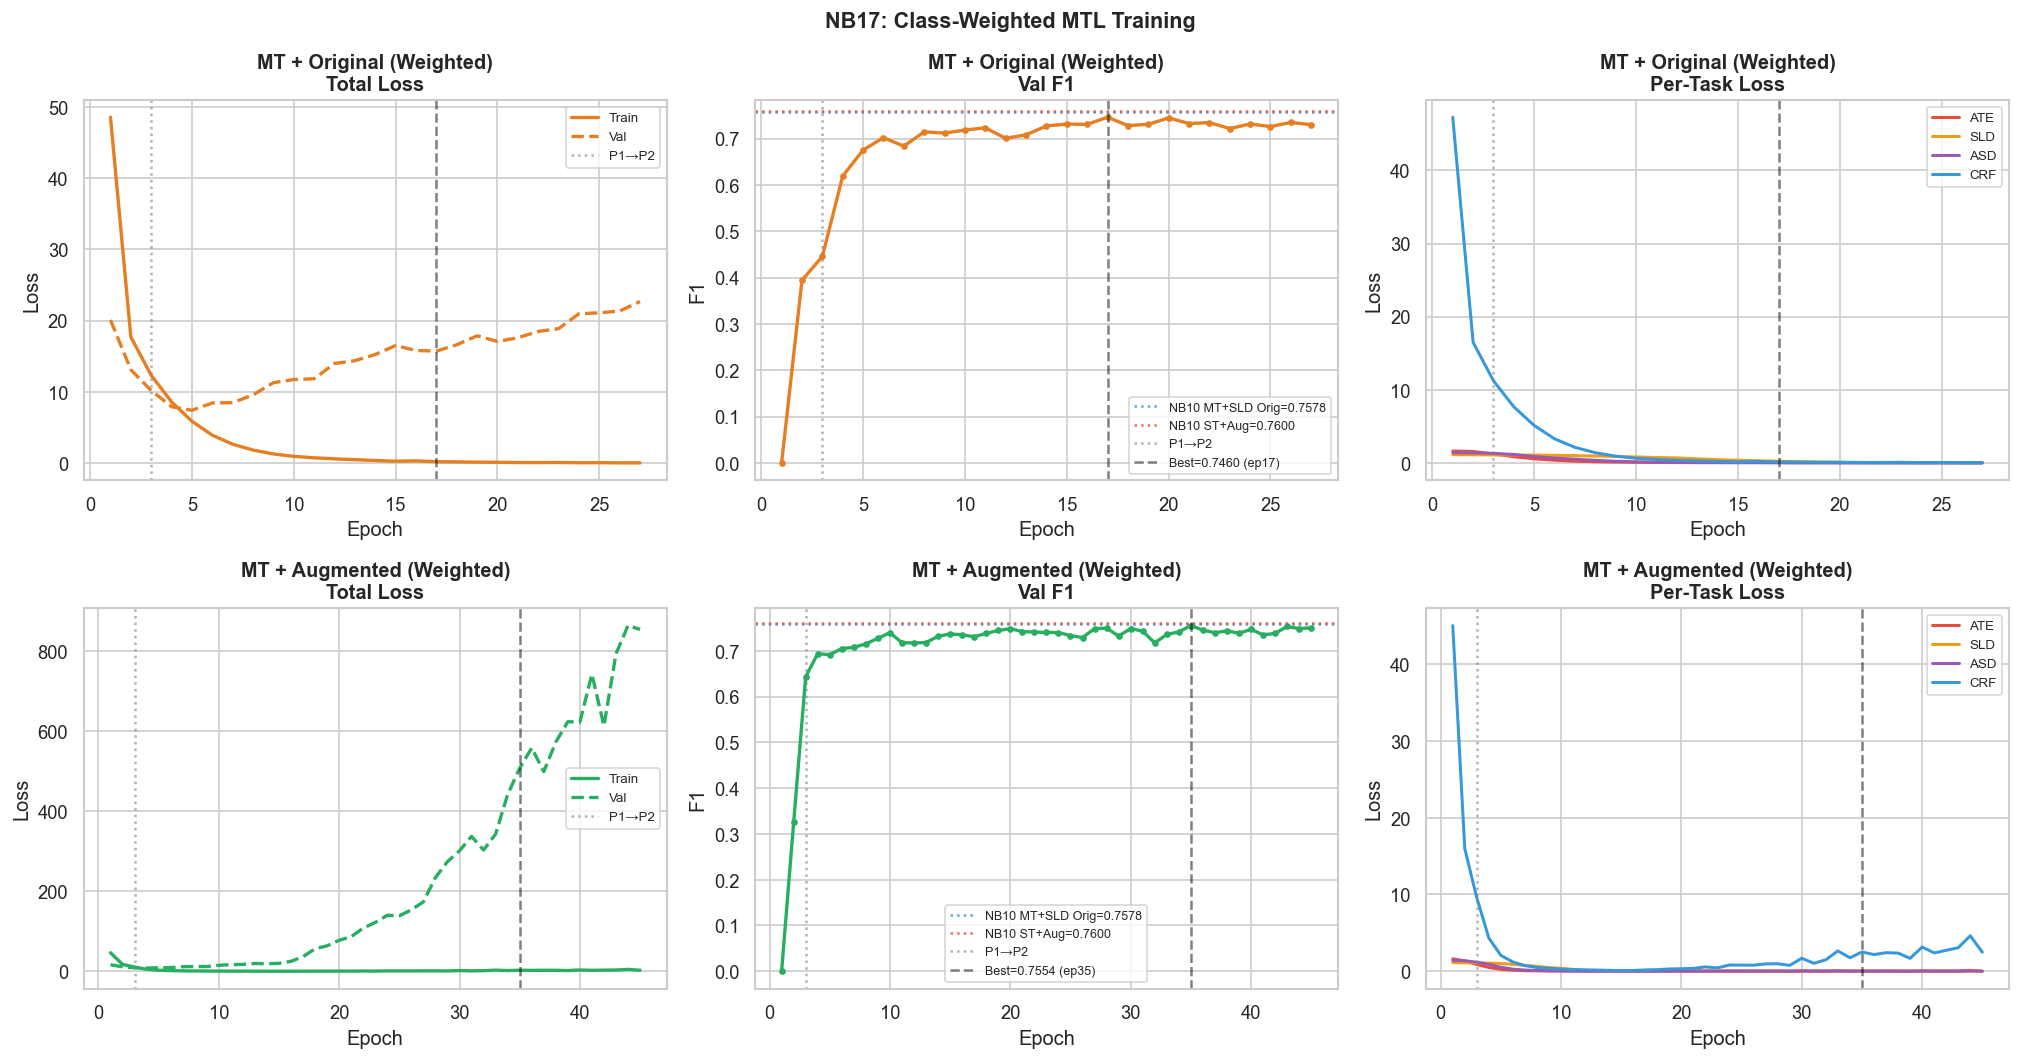

In [10]:
# Visualisasi training — 2 baris × 3 kolom
RUN_COLORS = {
    'MT + Original (Weighted)':  '#e67e22',
    'MT + Augmented (Weighted)': '#27ae60',
}
TASK_COLORS = {'ate': '#e74c3c', 'sld': '#f39c12', 'asd': '#9b59b6', 'crf': '#3498db'}

fig, axes = plt.subplots(2, 3, figsize=(17, 9))

for row, (run_name, res) in enumerate(all_results.items()):
    h       = res['history']
    ep      = range(1, len(h['train_loss']) + 1)
    color   = RUN_COLORS[run_name]
    best_ep = res['best_epoch']
    pb      = res['phase_boundary']  # end of Phase 1

    # Kolom 0: Total loss
    axes[row, 0].plot(ep, h['train_loss'], label='Train', color=color, lw=2)
    axes[row, 0].plot(ep, h['val_loss'],   label='Val',   color=color, lw=2, linestyle='--')
    axes[row, 0].axvline(pb,      color='gray',  linestyle=':',  alpha=0.6, label='P1→P2')
    axes[row, 0].axvline(best_ep, color='black', linestyle='--', alpha=0.5)
    axes[row, 0].set_title(f'{run_name}\nTotal Loss', fontweight='bold')
    axes[row, 0].set_xlabel('Epoch'); axes[row, 0].set_ylabel('Loss')
    axes[row, 0].legend(fontsize=8)

    # Kolom 1: Val F1
    axes[row, 1].plot(ep, h['val_f1'], color=color, lw=2, marker='o', markersize=3)
    axes[row, 1].axhline(NB10_MT_ORIG_F1, color='#3498db', linestyle=':', alpha=0.8,
                         label=f'NB10 MT+SLD Orig={NB10_MT_ORIG_F1:.4f}')
    axes[row, 1].axhline(NB10_ST_AUG_F1,  color='#e74c3c', linestyle=':', alpha=0.8,
                         label=f'NB10 ST+Aug={NB10_ST_AUG_F1:.4f}')
    axes[row, 1].axvline(pb,      color='gray',  linestyle=':',  alpha=0.6, label='P1→P2')
    axes[row, 1].axvline(best_ep, color='black', linestyle='--', alpha=0.5,
                         label=f'Best={res["best_f1"]:.4f} (ep{best_ep})')
    axes[row, 1].set_title(f'{run_name}\nVal F1', fontweight='bold')
    axes[row, 1].set_xlabel('Epoch'); axes[row, 1].set_ylabel('F1')
    axes[row, 1].legend(fontsize=7.5)

    # Kolom 2: Per-task losses
    for task, tc in TASK_COLORS.items():
        axes[row, 2].plot(ep, h[f'loss_{task}'], label=task.upper(), color=tc, lw=1.8)
    axes[row, 2].axvline(pb,      color='gray',  linestyle=':',  alpha=0.6)
    axes[row, 2].axvline(best_ep, color='black', linestyle='--', alpha=0.5)
    axes[row, 2].set_title(f'{run_name}\nPer-Task Loss', fontweight='bold')
    axes[row, 2].set_xlabel('Epoch'); axes[row, 2].set_ylabel('Loss')
    axes[row, 2].legend(fontsize=8)

plt.suptitle('NB17: Class-Weighted MTL Training', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

---
## PART 4 — Evaluation & Comparison

In [11]:
# Load best model per run, evaluasi final
for run_name, res in all_results.items():
    ckpt_path = os.path.join(MODEL_DIR, res['ckpt_name'])

    ate_w = torch.tensor(res['weights']['ate'], device=device)
    sld_w = torch.tensor(res['weights']['sld'], device=device)
    asd_w = torch.tensor(res['weights']['asd'], device=device)

    run_model = HierarchicalMultiTaskABSA(
        model_name=MODEL_NAME,
        num_ate=len(ate_labels), num_sld=len(sld_labels),
        num_asd=len(asd_labels), num_final=len(bieos_labels),
        proj_dim=PROJ_DIM, dropout=DROPOUT,
        ate_weights=ate_w, sld_weights=sld_w, asd_weights=asd_w,
        max_relative_position=MAX_REL_POS, lambda1=LAMBDA1, lambda2=LAMBDA2,
    ).to(device)
    run_model.load_state_dict(torch.load(ckpt_path, weights_only=True))

    vl = val_loader_orig if 'Original' in run_name else val_loader_aug
    _, f1, true, preds = evaluate(run_model, vl, device)

    all_results[run_name]['val_true']  = true
    all_results[run_name]['val_preds'] = preds
    all_results[run_name]['best_f1']   = f1

    print(f'=== NB17: {run_name} — Val F1: {f1:.4f} (best ep {res["best_epoch"]}) ===')
    print(classification_report(true, preds))

    del run_model
    gc.collect()
    torch.cuda.empty_cache()

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

=== NB17: MT + Original (Weighted) — Val F1: 0.7460 (best ep 17) ===
              precision    recall  f1-score   support

         NEG       0.58      0.64      0.61        83
         NEU       0.54      0.70      0.61       125
         POS       0.79      0.82      0.80       536

   micro avg       0.72      0.78      0.75       744
   macro avg       0.64      0.72      0.67       744
weighted avg       0.73      0.78      0.75       744



Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

=== NB17: MT + Augmented (Weighted) — Val F1: 0.7554 (best ep 35) ===
              precision    recall  f1-score   support

         NEG       0.58      0.58      0.58        83
         NEU       0.62      0.64      0.63       125
         POS       0.79      0.83      0.81       536

   micro avg       0.74      0.77      0.76       744
   macro avg       0.66      0.68      0.67       744
weighted avg       0.74      0.77      0.75       744



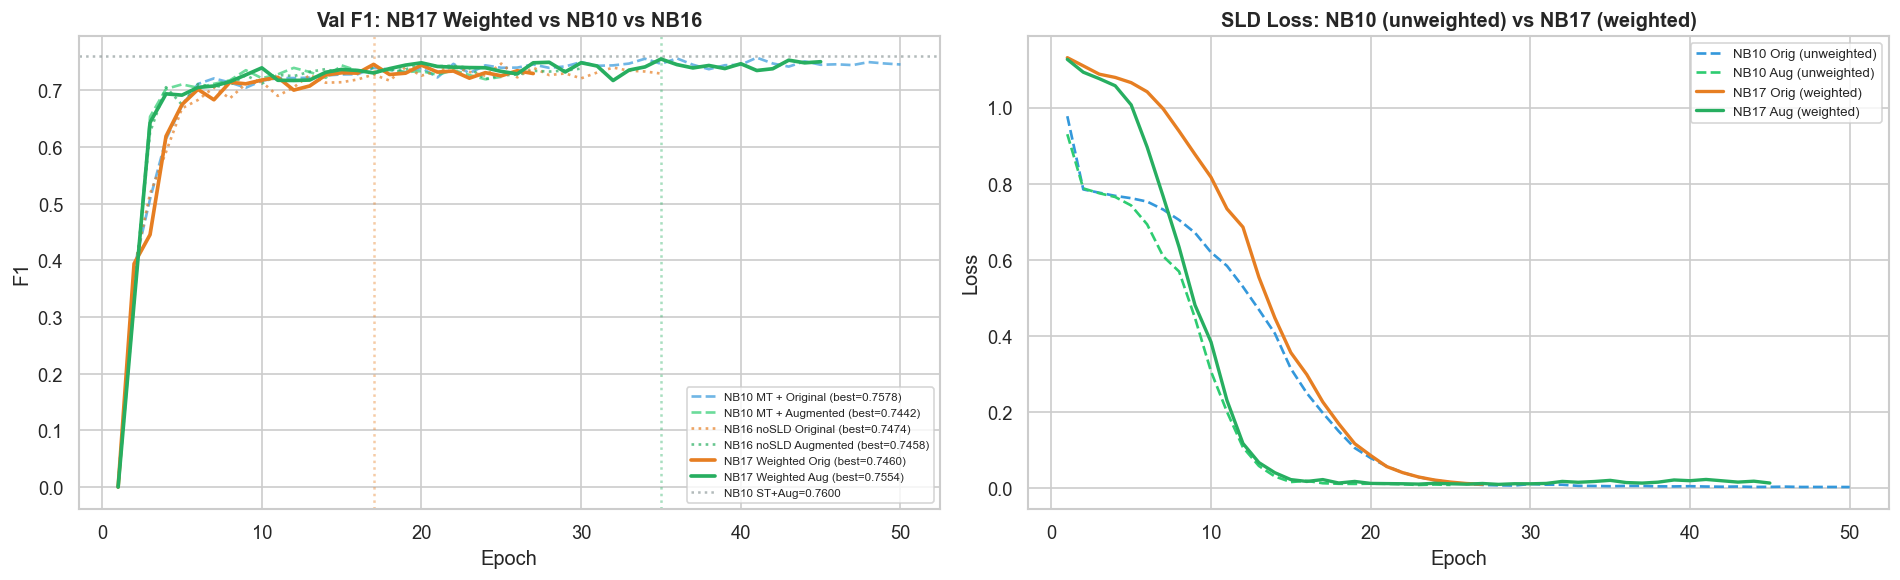

In [12]:
# Load NB10 & NB16 untuk comparison plots
from matplotlib.lines import Line2D

ckpt_nb10 = torch.load(os.path.join(MODEL_DIR, 'checkpoint_extended_training.pt'),
                        map_location='cpu', weights_only=False)
ckpt_nb16 = torch.load(os.path.join(MODEL_DIR, 'checkpoint_nosld.pt'),
                        map_location='cpu', weights_only=False)

nb10 = ckpt_nb10['results']
nb16 = ckpt_nb16['all_results']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel kiri: F1 curves
# NB10 referensi
for rn, color, ls in [
    ('MT + Original',  '#3498db', '--'),
    ('MT + Augmented', '#2ecc71', '--'),
]:
    h  = nb10[rn]['history']
    ep = range(1, len(h['val_f1']) + 1)
    axes[0].plot(ep, h['val_f1'], color=color, lw=1.6, linestyle=ls, alpha=0.7,
                 label=f'NB10 {rn} (best={nb10[rn]["best_f1"]:.4f})')

# NB16 (noSLD)
for rn, color, ls in [
    ('MT + Original',  '#e67e22', ':'),
    ('MT + Augmented', '#27ae60', ':'),
]:
    h  = nb16[rn]['history']
    ep = range(1, len(h['val_f1']) + 1)
    axes[0].plot(ep, h['val_f1'], color=color, lw=1.6, linestyle=ls, alpha=0.7,
                 label=f'NB16 noSLD {rn.split(" + ")[1]} (best={nb16[rn]["best_f1"]:.4f})')

# NB17 (weighted)
for run_name, res in all_results.items():
    h     = res['history']
    ep    = range(1, len(h['val_f1']) + 1)
    color = RUN_COLORS[run_name]
    axes[0].plot(ep, h['val_f1'], color=color, lw=2.2,
                 label=f'NB17 Weighted {"Orig" if "Original" in run_name else "Aug"} '
                       f'(best={res["best_f1"]:.4f})')
    axes[0].axvline(res['best_epoch'], color=color, linestyle=':', alpha=0.4)

axes[0].axhline(NB10_ST_AUG_F1, color='#7f8c8d', linestyle=':', alpha=0.6,
                label=f'NB10 ST+Aug={NB10_ST_AUG_F1:.4f}')
axes[0].set_title('Val F1: NB17 Weighted vs NB10 vs NB16', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('F1')
axes[0].legend(fontsize=7)

# Panel kanan: SLD loss comparison — NB10 vs NB17 (effect of weighting SLD)
for rn, label, color, ls in [
    ('MT + Original',  'NB10 Orig (unweighted)', '#3498db', '--'),
    ('MT + Augmented', 'NB10 Aug (unweighted)',  '#2ecc71', '--'),
]:
    h  = nb10[rn]['history']
    ep = range(1, len(h['val_f1']) + 1)
    axes[1].plot(ep, h['loss_sld'], color=color, lw=1.6, linestyle=ls, label=label)

for run_name, res in all_results.items():
    h     = res['history']
    ep    = range(1, len(h['val_f1']) + 1)
    color = RUN_COLORS[run_name]
    label = f'NB17 {"Orig" if "Original" in run_name else "Aug"} (weighted)'
    axes[1].plot(ep, h['loss_sld'], color=color, lw=2, label=label)

axes[1].set_title('SLD Loss: NB10 (unweighted) vs NB17 (weighted)', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [13]:
# Tabel perbandingan lengkap
print('=' * 92)
print(f'{"Model":<34} {"Data":^10} {"F1":^8} {"Best Ep":^8} {"Δ vs NB10 MT+Orig":^18}')
print('-' * 92)

rows = [
    ('NB03: MT+SLD (18ep)',       'Original',  NB03_MT_F1,      14,   None),
    ('NB07: ST Baseline',         'Original',  NB07_ST_F1,      None, None),
    ('NB10: MT+SLD (50ep)',       'Original',  NB10_MT_ORIG_F1, nb10['MT + Original']['best_epoch'],  0.0),
    ('NB10: ST (50ep)',           'Original',  NB10_ST_ORIG_F1, nb10['ST + Original']['best_epoch'],  None),
    ('NB10: MT+SLD (50ep)',       'Augmented', NB10_MT_AUG_F1,  nb10['MT + Augmented']['best_epoch'], None),
    ('NB10: ST (50ep)',           'Augmented', NB10_ST_AUG_F1,  nb10['ST + Augmented']['best_epoch'], None),
    ('NB16: MT-noSLD (50ep)',     'Original',  NB16_MT_ORIG_F1, nb16['MT + Original']['best_epoch'],  None),
    ('NB16: MT-noSLD (50ep)',     'Augmented', NB16_MT_AUG_F1,  nb16['MT + Augmented']['best_epoch'], None),
]
for name, data, f1, ep, delta in rows:
    ep_str    = str(ep) if ep else '-'
    delta_str = f'{delta:+.4f}' if delta is not None else '-'
    print(f'{name:<34} {data:^10} {f1:^8.4f} {ep_str:^8} {delta_str:^18}')

print()
for run_name, res in all_results.items():
    data  = 'Original' if 'Original' in run_name else 'Augmented'
    delta = res['best_f1'] - NB10_MT_ORIG_F1
    print(f'{"NB17: MT+SLD+Weight ◄":<34} {data:^10} {res["best_f1"]:^8.4f} '
          f'{res["best_epoch"]:^8} {delta:^+18.4f}')

print('=' * 92)
print(f'Prior research (EMC-GCN): {PRIOR_RESEARCH_F1}')
print()

orig_res = all_results.get('MT + Original (Weighted)')
aug_res  = all_results.get('MT + Augmented (Weighted)')
if orig_res and aug_res:
    d_10o = orig_res['best_f1'] - NB10_MT_ORIG_F1
    d_10a = aug_res['best_f1']  - NB10_MT_AUG_F1
    d_16o = orig_res['best_f1'] - NB16_MT_ORIG_F1
    d_16a = aug_res['best_f1']  - NB16_MT_AUG_F1
    print(f'NB17 Orig vs NB10 MT+Orig : {d_10o:+.4f}')
    print(f'NB17 Aug  vs NB10 MT+Aug  : {d_10a:+.4f}')
    print(f'NB17 Orig vs NB16 MT Orig : {d_16o:+.4f}  (efek weighting tanpa SLD removal)')
    print(f'NB17 Aug  vs NB16 MT Aug  : {d_16a:+.4f}  (efek weighting tanpa SLD removal)')
    print()
    if d_10a > 0.005:
        print('→ Class weighting SIGNIFIKAN membantu augmented data → O-dominance confirmed')
    elif d_10a > 0:
        print('→ Class weighting sedikit membantu augmented data → O-dominance sebagian terkonfirmasi')
    else:
        print('→ Class weighting tidak membantu / merugikan → O-dominance bukan penyebab utama')

Model                                 Data       F1    Best Ep  Δ vs NB10 MT+Orig 
--------------------------------------------------------------------------------------------
NB03: MT+SLD (18ep)                 Original   0.7410     14            -         
NB07: ST Baseline                   Original   0.7551     -             -         
NB10: MT+SLD (50ep)                 Original   0.7578     41         +0.0000      
NB10: ST (50ep)                     Original   0.7558     24            -         
NB10: MT+SLD (50ep)                Augmented   0.7442     15            -         
NB10: ST (50ep)                    Augmented   0.7600     21            -         
NB16: MT-noSLD (50ep)               Original   0.7474     25            -         
NB16: MT-noSLD (50ep)              Augmented   0.7458     20            -         

NB17: MT+SLD+Weight ◄               Original   0.7460     17         -0.0118      
NB17: MT+SLD+Weight ◄              Augmented   0.7554     35         -0.0024

In [14]:
# Per-class F1 comparison
from seqeval.metrics import classification_report as seq_cr

for run_name, res in all_results.items():
    print(f'=== NB17: {run_name} ===')
    print(seq_cr(res['val_true'], res['val_preds']))

print('=== NB10: MT+SLD (50ep) + Original ===')
print(seq_cr(nb10['MT + Original']['val_true'], nb10['MT + Original']['val_preds']))

print('=== NB10: MT+SLD (50ep) + Augmented ===')
print(seq_cr(nb10['MT + Augmented']['val_true'], nb10['MT + Augmented']['val_preds']))

print('=== NB10: ST (50ep) + Augmented [best overall] ===')
print(seq_cr(nb10['ST + Augmented']['val_true'], nb10['ST + Augmented']['val_preds']))

=== NB17: MT + Original (Weighted) ===
              precision    recall  f1-score   support

         NEG       0.58      0.64      0.61        83
         NEU       0.54      0.70      0.61       125
         POS       0.79      0.82      0.80       536

   micro avg       0.72      0.78      0.75       744
   macro avg       0.64      0.72      0.67       744
weighted avg       0.73      0.78      0.75       744

=== NB17: MT + Augmented (Weighted) ===
              precision    recall  f1-score   support

         NEG       0.58      0.58      0.58        83
         NEU       0.62      0.64      0.63       125
         POS       0.79      0.83      0.81       536

   micro avg       0.74      0.77      0.76       744
   macro avg       0.66      0.68      0.67       744
weighted avg       0.74      0.77      0.75       744

=== NB10: MT+SLD (50ep) + Original ===
              precision    recall  f1-score   support

         NEG       0.61      0.64      0.62        83
         NE

In [15]:
# Simpan checkpoint
checkpoint = {
    'all_results': all_results,
    'model_name':  MODEL_NAME,
    'config': {
        'architecture':         'HierarchicalMultiTaskABSA + class-weighted ATE/SLD/ASD losses',
        'loss_formula':         'lambda1*(L_ATE+L_SLD) + lambda2*L_ASD + L_CRF (weighted CE)',
        'weight_formula':       'sklearn balanced: w_c = N/(n_classes*count_c), normalized',
        'phase1_epochs':        PHASE1_EPOCHS,
        'sentiment_connection': True,
        'lambda1':              LAMBDA1,
        'lambda2':              LAMBDA2,
        'num_epochs':           NUM_EPOCHS,
        'patience':             PATIENCE,
        'seed':                 SEED,
        'lr_bert':              LR_BERT,
        'lr_head':              LR_HEAD,
        'dropout':              DROPOUT,
        'weight_decay':         WEIGHT_DECAY,
        'proj_dim':             PROJ_DIM,
        'max_len':              MAX_LENGTH,
        'train_ratio':          TRAIN_RATIO,
    },
    'reference': {
        'nb10_mt_orig_f1': NB10_MT_ORIG_F1,
        'nb10_mt_aug_f1':  NB10_MT_AUG_F1,
        'nb10_st_orig_f1': NB10_ST_ORIG_F1,
        'nb10_st_aug_f1':  NB10_ST_AUG_F1,
        'nb16_mt_orig_f1': NB16_MT_ORIG_F1,
        'nb16_mt_aug_f1':  NB16_MT_AUG_F1,
    },
}

save_path = os.path.join(MODEL_DIR, 'checkpoint_weighted_mtl.pt')
torch.save(checkpoint, save_path)

file_size = os.path.getsize(save_path) / (1024**2)
print(f'Checkpoint saved: {save_path} ({file_size:.0f} MB)')
for run_name, res in all_results.items():
    d_nb10 = res['best_f1'] - NB10_MT_ORIG_F1
    d_nb16 = res['best_f1'] - (NB16_MT_ORIG_F1 if 'Original' in run_name else NB16_MT_AUG_F1)
    print(f'  {run_name:<34}: F1={res["best_f1"]:.4f} (ep {res["best_epoch"]}) | '
          f'Δ NB10: {d_nb10:+.4f} | Δ NB16: {d_nb16:+.4f}')

Checkpoint saved: d:\Kuliah\TA\Notebook\models\checkpoint_weighted_mtl.pt (0 MB)
  MT + Original (Weighted)          : F1=0.7460 (ep 17) | Δ NB10: -0.0118 | Δ NB16: -0.0014
  MT + Augmented (Weighted)         : F1=0.7554 (ep 35) | Δ NB10: -0.0024 | Δ NB16: +0.0096
